# 1. Setup

Simple relative paths and notebook switches. GeoPandas is used only for reading GeoJSON files, CRS transformation, area calculation, and plotting. The spatial algorithms themselves are implemented manually with course-style Python classes.

In [1]:
import os
import glob
import csv
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
from numpy import sqrt, radians, arcsin, sin, cos

# --- Pfade konfigurieren ---
DATA_BASE_DIR = "./data/raw/DE"
GEOJSON_PARKS = "./data/raw/park_polygons.geojson"
GEOJSON_CITIES = "./data/raw/city_polygons.geojson"

# Output-Dateien für spätere Nutzung
COMPILED_CSV = "./outputs/all_flickr_points.csv"
CANDIDATE_CSV = "./outputs/flickr_bbox_candidates.csv"
FILTERED_CSV = "./outputs/filtered_flickr_inside_polygons.csv"
NNI_RESULTS_CSV = "./outputs/nni_results_sampled.csv"
NNI_QUERY_RESULTS_CSV = "./outputs/nni_results_sampled_query.csv"

# Sample-Schalter für schnelles Testen
USE_DATA_SAMPLE = False
SAMPLE_MAX_FILES = 12
SAMPLE_ROWS_PER_FILE = 5000

# Cache-Schalter: auf True setzen, wenn Outputs neu gebaut werden sollen
REBUILD_COMPILED_CACHE = False
REBUILD_CANDIDATE_CACHE = False
REBUILD_PIP_RESULTS = False
REBUILD_NNI_RESULTS = False

# Spatial-index und NNI Einstellungen
GLOBAL_INDEX_RESOLUTION = 0.05
NNI_INDEX_RESOLUTION = 0.01
NNI_SAMPLE_SIZE = 5000
RANDOM_SEED = 42
CSV_CHUNK_SIZE = 500000

# Verhindert Pandas DtypeWarnings beim Lesen der großen gecachten CSVs.
MIXED_TYPE_DTYPES = {"ID": "string", "PhotoID": "string", "Views": "string", "MTags": "string"}

os.makedirs("./outputs", exist_ok=True)

print("Setup abgeschlossen.")

Setup abgeschlossen.


# 2. Data Preparation

The Flickr data are loaded recursively from `./data/raw/DE`. All `settings.txt` files are excluded. Coordinates are cleaned, photos are deduplicated by `PhotoID`, and the cleaned point table is cached in `./outputs/all_flickr_points.csv`.

Some descriptive fields, especially `PhotoID`, `Views`, and `MTags`, can look numeric in some rows and textual or empty in others. These fields are therefore read as strings in later cached reads. This avoids Pandas `DtypeWarning` messages and does not affect the spatial algorithms, because only `Latitude` and `Longitude` are used as coordinates.

In [2]:
FLICKR_COLUMNS = [
    "ID", "Latitude", "Longitude", "NAME", "URL", "PhotoID", "Owner", "UserID",
    "DateTaken", "UploadDate", "Views", "Tags", "MTags"
]


def find_flickr_files(base_dir):
    all_txt_files = sorted(glob.glob(os.path.join(base_dir, "**", "*.txt"), recursive=True))
    data_files = [f for f in all_txt_files if os.path.basename(f).lower() != "settings.txt"]
    settings_files = [f for f in all_txt_files if os.path.basename(f).lower() == "settings.txt"]
    return data_files, settings_files


def validate_headers(files):
    header_counts = defaultdict(int)
    for file_path in files:
        with open(file_path, "r", encoding="utf-8", errors="replace", newline="") as f:
            reader = csv.reader(f)
            header = tuple(next(reader))
            header_counts[header] += 1

    print(f"Flickr data files gefunden: {len(files)}")
    print(f"settings.txt Dateien ausgeschlossen: {len(settings_files)}")
    print(f"Header-Varianten gefunden: {len(header_counts)}")

    for header, count in header_counts.items():
        print(f"{count} Dateien mit Header: {header}")
        if list(header) != FLICKR_COLUMNS:
            raise ValueError("Unerwarteter Header in den Flickr-Dateien.")


flickr_files, settings_files = find_flickr_files(DATA_BASE_DIR)
validate_headers(flickr_files)

Flickr data files gefunden: 403
settings.txt Dateien ausgeschlossen: 90
Header-Varianten gefunden: 1
403 Dateien mit Header: ('ID', 'Latitude', 'Longitude', 'NAME', 'URL', 'PhotoID', 'Owner', 'UserID', 'DateTaken', 'UploadDate', 'Views', 'Tags', 'MTags')


In [3]:
def compile_raw_flickr_data(files, output_csv):
    if os.path.exists(output_csv) and not REBUILD_COMPILED_CACHE:
        print(f"Lade bereits kompilierte Daten von {output_csv}...")
        return output_csv

    files_to_read = files[:SAMPLE_MAX_FILES] if USE_DATA_SAMPLE else files
    seen_photo_ids = set()
    rows_read = 0
    rows_written = 0
    duplicate_rows = 0
    invalid_rows = 0

    with open(output_csv, "w", encoding="utf-8", newline="") as out_file:
        wrote_header = False

        for i, file_path in enumerate(files_to_read, start=1):
            nrows = SAMPLE_ROWS_PER_FILE if USE_DATA_SAMPLE else None
            df = pd.read_csv(
                file_path,
                usecols=FLICKR_COLUMNS,
                nrows=nrows,
                dtype=MIXED_TYPE_DTYPES,
                on_bad_lines="skip",
                low_memory=False
            )
            rows_read += len(df)

            df["Latitude"] = pd.to_numeric(df["Latitude"], errors="coerce")
            df["Longitude"] = pd.to_numeric(df["Longitude"], errors="coerce")
            valid_coords = df["Latitude"].between(-90, 90) & df["Longitude"].between(-180, 180)
            invalid_rows += int((~valid_coords).sum())
            df = df.loc[valid_coords].copy()

            df["PhotoID"] = df["PhotoID"].astype(str)
            before_file_dedup = len(df)
            df = df.drop_duplicates(subset="PhotoID", keep="first").copy()
            duplicate_rows += before_file_dedup - len(df)

            already_seen = df["PhotoID"].isin(seen_photo_ids)
            duplicate_rows += int(already_seen.sum())
            df = df.loc[~already_seen].copy()
            seen_photo_ids.update(df["PhotoID"].tolist())

            df.to_csv(out_file, index=False, header=not wrote_header)
            wrote_header = True
            rows_written += len(df)

            if i % 25 == 0 or i == len(files_to_read):
                print(f"Verarbeitet: {i}/{len(files_to_read)} Dateien | gespeicherte Punkte: {rows_written:,}")

    print("\nKompilieren abgeschlossen.")
    print(f"Gelesene Zeilen: {rows_read:,}")
    print(f"Gespeicherte Zeilen: {rows_written:,}")
    print(f"Duplikate nach PhotoID entfernt: {duplicate_rows:,}")
    print(f"Ungültige Koordinaten entfernt: {invalid_rows:,}")
    return output_csv


compile_raw_flickr_data(flickr_files, COMPILED_CSV)
pd.read_csv(COMPILED_CSV, nrows=5, dtype=MIXED_TYPE_DTYPES, low_memory=False)

Verarbeitet: 25/403 Dateien | gespeicherte Punkte: 1,161,120
Verarbeitet: 50/403 Dateien | gespeicherte Punkte: 2,095,451
Verarbeitet: 75/403 Dateien | gespeicherte Punkte: 2,965,150
Verarbeitet: 100/403 Dateien | gespeicherte Punkte: 3,910,663
Verarbeitet: 125/403 Dateien | gespeicherte Punkte: 4,862,477
Verarbeitet: 150/403 Dateien | gespeicherte Punkte: 5,680,643
Verarbeitet: 175/403 Dateien | gespeicherte Punkte: 6,734,259
Verarbeitet: 200/403 Dateien | gespeicherte Punkte: 7,660,503
Verarbeitet: 225/403 Dateien | gespeicherte Punkte: 8,349,072
Verarbeitet: 250/403 Dateien | gespeicherte Punkte: 8,826,406
Verarbeitet: 275/403 Dateien | gespeicherte Punkte: 9,198,059
Verarbeitet: 300/403 Dateien | gespeicherte Punkte: 10,119,235
Verarbeitet: 325/403 Dateien | gespeicherte Punkte: 10,833,032
Verarbeitet: 350/403 Dateien | gespeicherte Punkte: 11,760,081
Verarbeitet: 375/403 Dateien | gespeicherte Punkte: 12,644,894
Verarbeitet: 400/403 Dateien | gespeicherte Punkte: 13,530,173
Verarb

,ID,Latitude,Longitude,NAME,URL,PhotoID,Owner,UserID,DateTaken,UploadDate,Views,Tags,MTags
0,1,49.037234,7.941784,Wissembourg; Bas-Rhin; le cloître (2),https://farm3.staticflickr.com/2618/3755526678...,3755526678,roger joseph,32305224@N07,7/22/2009 16:00:42,7/25/2009 16:53:04,18,;alsace;églisesgothiques;,<NA>
1,2,49.037234,7.941784,Wissembourg; Bas-Rhin (2),https://farm3.staticflickr.com/2493/3754721477...,3754721477,roger joseph,32305224@N07,7/22/2009 15:48:48,7/25/2009 16:51:16,20,;alsace;églisesgothiques;,<NA>
2,3,49.037234,7.941784,Wissembourg; Bas-Rhin (3),https://farm4.staticflickr.com/3467/3755522558...,3755522558,roger joseph,32305224@N07,7/22/2009 15:49:56,7/25/2009 16:51:30,26,;alsace;églisesgothiques;,<NA>
3,4,49.037234,7.941784,Wissembourg; Bas-Rhin (7),https://farm3.staticflickr.com/2605/3754723413...,3754723413,roger joseph,32305224@N07,7/22/2009 15:52:56,7/25/2009 16:52:01,26,;alsace;églisesgothiques;,<NA>
4,5,49.037234,7.941784,Wissembourg; Bas-Rhin (20),https://farm3.staticflickr.com/2435/3755524714...,3755524714,roger joseph,32305224@N07,7/22/2009 16:06:14,7/25/2009 16:52:18,19,;alsace;églisesgothiques;,<NA>


In [4]:
def load_polygon_data(city_path, park_path):
    polygon_records = []

    layers = [
        ("City", city_path, "Geografisc"),
        ("Park", park_path, "NAME"),
    ]

    for poly_type, path, name_field in layers:
        gdf_original = gpd.read_file(path)
        print(f"{poly_type} CRS vorher: {gdf_original.crs}")

        # GeoPandas nur zum Einlesen, Transformieren und für Flächen in Quadratmetern.
        gdf_lonlat = gdf_original.to_crs(epsg=4326)
        gdf_metric = gdf_original.to_crs(epsg=25832)

        print(f"{poly_type} Bounds nach EPSG:4326: {tuple(round(v, 5) for v in gdf_lonlat.total_bounds)}")

        for idx, row in gdf_lonlat.iterrows():
            geom = row.geometry
            base_name = row[name_field] if name_field in row and pd.notna(row[name_field]) else f"{poly_type}_{idx}"
            poly_name = f"{poly_type}_{base_name}"
            area_m2 = float(gdf_metric.geometry.iloc[idx].area)

            if geom.geom_type == "Polygon":
                parts = [geom]
            elif geom.geom_type == "MultiPolygon":
                parts = list(geom.geoms)
            else:
                continue

            for part_id, part in enumerate(parts):
                exterior = [(float(x), float(y)) for x, y in part.exterior.coords]
                holes = [[(float(x), float(y)) for x, y in ring.coords] for ring in part.interiors]
                polygon_records.append({
                    "name": poly_name,
                    "type": poly_type,
                    "part_id": part_id,
                    "exterior": exterior,
                    "holes": holes,
                    "area_m2": area_m2,
                    "geometry": part,
                })

    return polygon_records


polygon_records = load_polygon_data(GEOJSON_CITIES, GEOJSON_PARKS)
print(f"Polygon-Objekte vorbereitet: {len(polygon_records)}")
print(f"Polygone mit Löchern: {sum(1 for p in polygon_records if p['holes'])}")

City CRS vorher: EPSG:25832
City Bounds nach EPSG:4326: (np.float64(6.68982), np.float64(48.06155), np.float64(13.76047), np.float64(53.73847))
Park CRS vorher: EPSG:4326
Park Bounds nach EPSG:4326: (np.float64(6.58083), np.float64(47.5324), np.float64(13.83964), np.float64(55.09917))
Polygon-Objekte vorbereitet: 20
Polygone mit Löchern: 4


# 3. Spatial Algorithms

Course-style classes for the three manual algorithms. The code follows the logic from the practical notebooks: point distances, bounding boxes, line/segment logic, point-in-polygon, and grid-based point indexing.

In [5]:
class Point():
    # initialise
    def __init__(self, x=None, y=None, pid=None, attrs=None):
        self.x = float(x)
        self.y = float(y)
        self.id = pid
        self.attributes = attrs or {}

    # representation
    def __repr__(self):
        return f"Point(x={self.x}, y={self.y})"

    # test for equality between two points
    def __eq__(self, other):
        if not isinstance(other, Point):
            return NotImplemented
        return self.x == other.x and self.y == other.y

    def isEqual(self, other):
        return self.x == other.x and self.y == other.y

    def __hash__(self):
        return hash((self.x, self.y))

    # calculate Euclidean distance between two points
    def distEuclidean(self, other):
        return sqrt((self.x - other.x)**2 + (self.y - other.y)**2)

    # Haversine distance between two lon/lat points, returned in metres
    def distHaversine(self, other):
        r = 6371000
        phi1 = radians(self.y)
        phi2 = radians(other.y)
        lam1 = radians(self.x)
        lam2 = radians(other.x)

        d = 2 * r * arcsin(sqrt(
            sin((phi2 - phi1) / 2)**2 +
            cos(phi1) * cos(phi2) * sin((lam2 - lam1) / 2)**2
        ))
        return float(d)

    # determine position of this point in relation to a vector of two other points
    def sideLine(self, p1, p2):
        side = int((p2.x - p1.x) * (self.y - p1.y) - (self.x - p1.x) * (p2.y - p1.y))
        if side != 0:
            side = side / abs(side)
        return side


class Bbox():
    # initialise
    def __init__(self, data):
        if isinstance(data, Segment):
            x = [data.start.x, data.end.x]
            y = [data.start.y, data.end.y]
        else:
            x = [p.x for p in data]
            y = [p.y for p in data]

        self.ll = Point(min(x), min(y))
        self.ur = Point(max(x), max(y))
        self.ctr = Point((min(x) + max(x)) / 2, (min(y) + max(y)) / 2)
        self.area = abs(max(x) - min(x)) * abs(max(y) - min(y))

    def __repr__(self):
        return f"Bounding box with lower-left {self.ll} and upper-right {self.ur}"

    def testOverlap(self, other):
        if (self.ur.x >= other.ll.x and other.ur.x >= self.ll.x and
            self.ur.y >= other.ll.y and other.ur.y >= self.ll.y):
            return True
        return False

    def containsPoint(self, p):
        if (self.ur.x >= p.x >= self.ll.x and self.ur.y >= p.y >= self.ll.y):
            return True
        return False

    def intersectsRegion(self, other):
        if not self.testOverlap(other):
            return None
        llx = max(self.ll.x, other.ll.x)
        lly = max(self.ll.y, other.ll.y)
        urx = min(self.ur.x, other.ur.x)
        ury = min(self.ur.y, other.ur.y)
        return Bbox([Point(llx, lly), Point(urx, ury)])


class Segment():
    # initialise
    def __init__(self, p0, p1, sid=None):
        self.start = p0
        self.end = p1
        self.sid = sid
        self.length = p0.distEuclidean(p1)

    def __repr__(self):
        return f"Segment with start {self.start} and end {self.end}."

    def intersects(self, other):
        self_bbox = Bbox(self)
        other_bbox = Bbox(other)
        bbox_overlap = self_bbox.testOverlap(other_bbox)

        if bbox_overlap == False:
            return False

        apq = self.start.sideLine(other.start, other.end)
        bpq = self.end.sideLine(other.start, other.end)
        pab = other.start.sideLine(self.start, self.end)
        qab = other.end.sideLine(self.start, self.end)

        if (apq + bpq == 0 and pab + qab == 0):
            return True
        return False


class CoursePolygon():
    # child-style polygon class adapted from the point-in-polygon practical
    def __init__(self, exterior=None, holes=None, name="", poly_type="", area_m2=0):
        self.points = [Point(x, y) for x, y in exterior]
        if self.points[0] != self.points[-1]:
            self.points.append(self.points[0])

        self.holes = []
        for ring in holes or []:
            hole_points = [Point(x, y) for x, y in ring]
            if hole_points and hole_points[0] != hole_points[-1]:
                hole_points.append(hole_points[0])
            self.holes.append(hole_points)

        self.size = len(self.points)
        self.name = name
        self.poly_type = poly_type
        self.area_m2 = area_m2
        self.bbox = Bbox(self.points)

    def __repr__(self):
        return f"CoursePolygon(name={self.name}, type={self.poly_type}, points={self.size}, holes={len(self.holes)})"

    def __getitem__(self, key):
        return self.points[key]

    def isClosed(self):
        return self.points[0] == self.points[-1]

    def _ringContainsPoint(self, p, ring_points):
        count = 0
        for i in range(0, len(ring_points) - 1):
            start = ring_points[i]
            end = ring_points[i + 1]

            if (p.y > min(start.y, end.y)):
                if (p.y <= max(start.y, end.y)):
                    if (p.x <= max(start.x, end.x)):
                        if (start.y != end.y):
                            x_intersection = start.x + (p.y - start.y) * (end.x - start.x) / (end.y - start.y)
                            if p.x <= x_intersection:
                                count += 1

        return count % 2 != 0

    def containsPoint(self, p):
        if self.bbox.containsPoint(p) == False:
            return False

        if self._ringContainsPoint(p, self.points) == False:
            return False

        # Interior rings are holes, so points inside holes are outside the polygon.
        for hole in self.holes:
            if self._ringContainsPoint(p, hole):
                return False

        return True

In [6]:
def build_course_polygons(records):
    polygons = []
    for record in records:
        polygons.append(CoursePolygon(
            exterior=record["exterior"],
            holes=record["holes"],
            name=record["name"],
            poly_type=record["type"],
            area_m2=record["area_m2"]
        ))
    return polygons


all_polygons = build_course_polygons(polygon_records)
print(f"Manuelle Polygone erstellt: {len(all_polygons)}")
print(all_polygons[0])

# Kleiner PIP-Test mit Loch
sample_polygon = CoursePolygon(
    exterior=[[0, 0], [10, 0], [10, 10], [0, 10], [0, 0]],
    holes=[[[3, 3], [7, 3], [7, 7], [3, 7], [3, 3]]],
    name="Sample",
    poly_type="Test",
    area_m2=100
)
assert sample_polygon.containsPoint(Point(2, 2)) == True
assert sample_polygon.containsPoint(Point(5, 5)) == False
assert sample_polygon.containsPoint(Point(12, 2)) == False
print("PIP-Test bestanden.")

Manuelle Polygone erstellt: 20
CoursePolygon(name=City_Hamburg, type=City, points=1227, holes=0)
PIP-Test bestanden.


## 3.1 Spatial Indexing

The Flickr dataset is too large to test every point against every polygon directly. The spatial index follows practical 6: the study area is divided into regular grid cells, and each `Point` is assigned to one cell based on its longitude and latitude.

For this project the grid is used in two steps. First, the compiled Flickr table is filtered with polygon bounding boxes so only points near the selected cities and parks are kept as candidates. Second, those candidates are inserted into a `PointIndex`. When a polygon is processed, the index only reads cells intersecting the polygon bounding box, instead of scanning all Flickr points again. This keeps the expensive point-in-polygon checks focused on relevant candidate points.

The grid index is an acceleration structure only: it does not decide whether a point is inside a polygon. It only reduces the search space before the exact manual point-in-polygon algorithm is applied.

In [7]:
class PointIndex():
    # initialise the index
    def __init__(self, data, box=None, res=0.05):
        self.res = res
        self.bBox = box if box else Bbox(data)
        w = self.bBox.ur.x - self.bBox.ll.x
        h = self.bBox.ur.y - self.bBox.ll.y
        self.nCols = int(w / self.res) + 1
        self.nRows = int(h / self.res) + 1

        ur = Point(
            self.bBox.ll.x + (self.nCols * self.res),
            self.bBox.ll.y + (self.nRows * self.res)
        )
        self.bBox = Bbox([self.bBox.ll, ur])
        self.maxIndex = (self.nCols * self.nRows) - 1
        self.points = [[0, []] for _ in range(self.maxIndex + 1)]
        self.bigArray = []

        self.addPoints(data)

    def __repr__(self):
        return f"PointIndex(res={self.res}, nCols={self.nCols}, nRows={self.nRows}, points={len(self.bigArray)})"

    def addPoints(self, data):
        for p in data:
            self.addPoint(p)
            self.bigArray.append(p)

    def addPoint(self, p):
        i = self.pointIndex(p)
        if 0 <= i <= self.maxIndex:
            self.points[i][0] += 1
            self.points[i][1].append(p)

    def pointIndex(self, p):
        j = int((p.y - self.bBox.ll.y) / self.res)
        i = int((p.x - self.bBox.ll.x) / self.res)
        return (j * self.nCols) + i

    def regionQuery(self, region):
        query = self.bBox.intersectsRegion(region)
        if query is None:
            return [], 0

        c_start = max(0, int((query.ll.x - self.bBox.ll.x) / self.res))
        c_end = min(self.nCols - 1, int((query.ur.x - self.bBox.ll.x) / self.res))
        r_start = max(0, int((query.ll.y - self.bBox.ll.y) / self.res))
        r_end = min(self.nRows - 1, int((query.ur.y - self.bBox.ll.y) / self.res))

        ps = []
        for r in range(r_start, r_end + 1):
            for c in range(c_start, c_end + 1):
                index = (r * self.nCols) + c
                if 0 <= index <= self.maxIndex and self.points[index][0] > 0:
                    ps.extend(self.points[index][1])

        final = []
        for p in ps:
            if region.containsPoint(p):
                final.append(p)

        return final, len(final)

    def bruteRegionQuery(self, region):
        final = []
        for p in self.bigArray:
            if region.containsPoint(p):
                final.append(p)
        return final, len(final)

    def nearestPoint(self, p, method="haversine"):
        # Course practical 6 idea: start with nearby cells, then expand until candidates exist.
        step = self.res
        max_step = max(self.bBox.ur.x - self.bBox.ll.x, self.bBox.ur.y - self.bBox.ll.y) + self.res
        ps = []

        while len(ps) == 0 and step <= max_step:
            ll = Point(p.x - step, p.y - step)
            ur = Point(p.x + step, p.y + step)
            box = Bbox([ll, ur])
            ps, count = self.regionQuery(box)
            ps = [q for q in ps if q is not p]
            step = step + self.res

        if len(ps) == 0:
            return None, None

        old_count = len(ps)
        nearest_point, nearest_distance = self.__minDist(ps, p, method=method)

        # Re-query a box based on the current nearest distance, as in practical 6.
        if method == "haversine":
            lat_buffer = nearest_distance / 111320.0
            lon_buffer = nearest_distance / (111320.0 * max(math.cos(math.radians(p.y)), 0.01))
        else:
            lat_buffer = nearest_distance
            lon_buffer = nearest_distance

        ll = Point(p.x - lon_buffer, p.y - lat_buffer)
        ur = Point(p.x + lon_buffer, p.y + lat_buffer)
        ps2, count = self.regionQuery(Bbox([ll, ur]))
        ps2 = [q for q in ps2 if q is not p]

        if count > old_count and len(ps2) > 0:
            nearest_point, nearest_distance = self.__minDist(ps2, p, method=method)

        return nearest_point, nearest_distance

    def __minDist(self, points, p, method="haversine"):
        best_point = None
        best_distance = float("inf")
        for q in points:
            if method == "haversine":
                d = p.distHaversine(q)
            else:
                d = p.distEuclidean(q)
            if d < best_distance:
                best_point = q
                best_distance = d
        return best_point, best_distance

In [8]:
def bbox_prefilter_flickr_points(compiled_csv, output_csv, polygons):
    if os.path.exists(output_csv) and not REBUILD_CANDIDATE_CACHE:
        print(f"Lade Bounding-Box-Kandidaten aus {output_csv}...")
        return output_csv

    polygon_bboxes = [(p.bbox.ll.x, p.bbox.ll.y, p.bbox.ur.x, p.bbox.ur.y) for p in polygons]
    total_rows = 0
    total_candidates = 0

    with open(output_csv, "w", encoding="utf-8", newline="") as out_file:
        wrote_header = False
        for chunk_no, chunk in enumerate(pd.read_csv(compiled_csv, chunksize=CSV_CHUNK_SIZE, dtype=MIXED_TYPE_DTYPES, low_memory=False), start=1):
            total_rows += len(chunk)
            lons = chunk["Longitude"].to_numpy(dtype=float)
            lats = chunk["Latitude"].to_numpy(dtype=float)
            mask = np.zeros(len(chunk), dtype=bool)

            for minx, miny, maxx, maxy in polygon_bboxes:
                mask |= ((lons >= minx) & (lons <= maxx) & (lats >= miny) & (lats <= maxy))

            candidates = chunk.loc[mask].copy()
            total_candidates += len(candidates)
            candidates.to_csv(out_file, index=False, header=not wrote_header)
            wrote_header = True

            if chunk_no % 10 == 0:
                print(f"Chunks: {chunk_no} | Zeilen geprüft: {total_rows:,} | Kandidaten: {total_candidates:,}")

    print(f"Bounding-Box Pre-Filter abgeschlossen: {total_rows:,} -> {total_candidates:,} Kandidaten")
    return output_csv


def point_from_row(row):
    attrs = {col: getattr(row, col) for col in FLICKR_COLUMNS if hasattr(row, col)}
    return Point(row.Longitude, row.Latitude, pid=row.PhotoID, attrs=attrs)


bbox_prefilter_flickr_points(COMPILED_CSV, CANDIDATE_CSV, all_polygons)
candidate_df = pd.read_csv(CANDIDATE_CSV, dtype=MIXED_TYPE_DTYPES, low_memory=False)
spatial_points = [point_from_row(row) for row in candidate_df.itertuples(index=False)]

print(f"Kandidatenpunkte für die Algorithmen: {len(spatial_points):,}")
if len(spatial_points) == 0:
    raise ValueError("Keine Kandidatenpunkte gefunden. Bitte CRS und Polygon-Bounds prüfen.")

global_grid = PointIndex(spatial_points, res=GLOBAL_INDEX_RESOLUTION)
print(global_grid)

# Test: Index-Abfrage gegen brute force auf kleinem Subset
subset = spatial_points[:min(5000, len(spatial_points))]
subset_index = PointIndex(subset, res=GLOBAL_INDEX_RESOLUTION)
indexed_points, indexed_count = subset_index.regionQuery(all_polygons[0].bbox)
brute_points, brute_count = subset_index.bruteRegionQuery(all_polygons[0].bbox)
assert indexed_count == brute_count
print(f"Spatial-Index-Test bestanden: {indexed_count} == {brute_count}")

Chunks: 10 | Zeilen geprüft: 5,000,000 | Kandidaten: 1,331,573
Chunks: 20 | Zeilen geprüft: 10,000,000 | Kandidaten: 3,497,601
Bounding-Box Pre-Filter abgeschlossen: 13,649,294 -> 3,497,601 Kandidaten
Kandidatenpunkte für die Algorithmen: 3,497,601
PointIndex(res=0.05, nCols=146, nRows=152, points=3497601)
Spatial-Index-Test bestanden: 0 == 0


## 3.2 Point in Polygon

The point-in-polygon algorithm follows the ray-casting idea from practical 4. For a test point, a horizontal ray is imagined from the point to the right. The algorithm counts how often this ray crosses the polygon boundary. If the number of crossings is odd, the point is inside; if the number is even, it is outside.

Before ray casting, every polygon uses its bounding box as a fast pre-check. Points outside this rectangle cannot be inside the polygon, so they are skipped immediately. The candidate points come from the spatial index, which means the exact ray-casting test is only applied to a much smaller set of points.

The park polygons contain interior rings, or holes. A point must be inside the exterior ring and outside all holes to be counted as inside the park. The notebook therefore checks the exterior first and then excludes points that fall inside any interior ring. The output keeps one row per point-polygon match, which allows city and park results to be summarized independently.

In [9]:
def run_point_in_polygon(polygons, point_index, output_csv):
    if os.path.exists(output_csv) and not REBUILD_PIP_RESULTS:
        print(f"Lade gespeicherte PIP-Ergebnisse aus {output_csv}...")
        return pd.read_csv(output_csv, dtype=MIXED_TYPE_DTYPES, low_memory=False)

    records = []

    for i, poly in enumerate(polygons, start=1):
        candidates, candidate_count = point_index.regionQuery(poly.bbox)
        inside_count = 0

        for p in candidates:
            if poly.containsPoint(p):
                row = p.attributes.copy()
                row["polygon_name"] = poly.name
                row["polygon_type"] = poly.poly_type
                row["polygon_area_m2"] = poly.area_m2
                records.append(row)
                inside_count += 1

        print(f"{i:02d}/{len(polygons)} {poly.name}: Kandidaten={candidate_count:,}, innen={inside_count:,}")

    output_columns = FLICKR_COLUMNS + ["polygon_name", "polygon_type", "polygon_area_m2"]
    result = pd.DataFrame(records, columns=output_columns)
    result.to_csv(output_csv, index=False)
    print(f"PIP abgeschlossen. Gespeicherte Treffer: {len(result):,}")
    return result


inside_points_df = run_point_in_polygon(all_polygons, global_grid, FILTERED_CSV)
inside_points_df.head()

01/20 City_Hamburg: Kandidaten=410,932, innen=357,867
02/20 City_Bremen: Kandidaten=79,735, innen=52,322
03/20 City_Düsseldorf: Kandidaten=120,566, innen=114,147
04/20 City_Köln: Kandidaten=228,583, innen=213,065
05/20 City_Dortmund: Kandidaten=53,965, innen=48,377
06/20 City_Frankfurt am Main: Kandidaten=244,613, innen=205,253
07/20 City_Stuttgart: Kandidaten=140,113, innen=128,815
08/20 City_München: Kandidaten=350,351, innen=337,843
09/20 City_Berlin: Kandidaten=1,106,229, innen=1,082,508
10/20 City_Leipzig: Kandidaten=95,401, innen=90,512
11/20 Park_Schleswig-Holsteinisches Wattenmeer: Kandidaten=44,874, innen=4,923
12/20 Park_Niedersächsisches Wattenmeer: Kandidaten=53,381, innen=6,318
13/20 Park_Bayerischer Wald: Kandidaten=20,370, innen=9,356
14/20 Park_Südschwarzwald: Kandidaten=109,910, innen=31,627
15/20 Park_Schwarzwald Mitte/Nord: Kandidaten=92,549, innen=32,130
16/20 Park_Bergstraße: Kandidaten=155,036, innen=26,057
17/20 Park_Fränkische Schweiz-Veldensteiner Forst: Kandid

,ID,Latitude,Longitude,NAME,URL,PhotoID,Owner,UserID,DateTaken,UploadDate,Views,Tags,MTags,polygon_name,polygon_type,polygon_area_m2
0,41042,53.430775,9.919569,Zentriert,https://farm8.staticflickr.com/7067/7035036113...,7035036113,fotoscheibe,51337247@N08,3/31/2012 19:35:30,4/01/2012 13:48:49,266,;deutschland;sonnenuntergang;hamburg;feld;gege...,NaN,City_Hamburg,City,7.365237e+08
1,41043,53.430775,9.919569,Flare,https://farm8.staticflickr.com/7210/7034969235...,7034969235,fotoscheibe,51337247@N08,3/31/2012 19:29:12,4/01/2012 13:20:30,163,;tree;deutschland;sonnenuntergang;hamburg;laub...,NaN,City_Hamburg,City,7.365237e+08
2,41044,53.430775,9.919569,Schatten,https://farm8.staticflickr.com/7080/6888874024...,6888874024,fotoscheibe,51337247@N08,3/31/2012 19:26:30,4/01/2012 13:19:58,298,;tree;deutschland;sonnenuntergang;hamburg;laub...,NaN,City_Hamburg,City,7.365237e+08
3,41045,53.430775,9.919569,Gegenlicht,https://farm8.staticflickr.com/7101/6888869976...,6888869976,fotoscheibe,51337247@N08,3/31/2012 19:24:35,4/01/2012 13:18:08,226,;tree;deutschland;sonnenuntergang;hamburg;laub...,NaN,City_Hamburg,City,7.365237e+08
4,41046,53.430775,9.919569,Dem Licht entgegen.,https://farm8.staticflickr.com/7101/6888866196...,6888866196,fotoscheibe,51337247@N08,3/31/2012 19:24:14,4/01/2012 13:16:29,150,;tree;deutschland;sonnenuntergang;hamburg;laub...,NaN,City_Hamburg,City,7.365237e+08


In [10]:
if len(inside_points_df) == 0:
    print("Keine Punkte innerhalb der Polygone gefunden.")
else:
    point_counts = (
        inside_points_df
        .groupby(["polygon_type", "polygon_name"])
        .size()
        .reset_index(name="point_count")
        .sort_values(["polygon_type", "point_count"], ascending=[True, False])
    )
    display(point_counts)

,polygon_type,polygon_name,point_count
0,City,City_Berlin,1082508
5,City,City_Hamburg,357867
8,City,City_München,337843
6,City,City_Köln,213065
4,City,City_Frankfurt am Main,205253
9,City,City_Stuttgart,128815
3,City,City_Düsseldorf,114147
7,City,City_Leipzig,90512
1,City,City_Bremen,52322
2,City,City_Dortmund,48377


## 3.3a Sampled / Thinned Nearest Neighbor Index

This cell keeps the first faster NNI approach as a comparison method. It creates a random subset of up to `NNI_SAMPLE_SIZE` points per polygon and computes NNI inside that subset. In other words, both the query points and the possible nearest neighbors come from the same thinned sample.

This is useful as a fast approximation and fallback, but it should be interpreted as the NNI of a random 5,000-point thinning of each polygon, not as the exact NNI of the full Flickr point pattern. The next cell adds a more realistic sampled-query NNI that keeps all points available as possible nearest neighbors.

In [11]:
def df_to_points(df):
    return [point_from_row(row) for row in df.itertuples(index=False)]


def sample_polygon_points(group, max_points=NNI_SAMPLE_SIZE):
    total_points = len(group)
    if total_points > max_points:
        sampled = group.sample(n=max_points, random_state=RANDOM_SEED).copy()
    else:
        sampled = group.copy()
    return sampled, total_points, len(sampled)


def compute_sampled_nni(points_list, area_m2):
    n = len(points_list)
    if n < 2 or area_m2 <= 0:
        return None

    local_index = PointIndex(points_list, res=NNI_INDEX_RESOLUTION)
    distances = []

    for p in points_list:
        nearest_point, nearest_distance = local_index.nearestPoint(p, method="haversine")
        if nearest_distance is not None:
            distances.append(nearest_distance)

    if len(distances) == 0:
        return None

    observed_mean_distance = sum(distances) / len(distances)
    point_density = n / area_m2
    expected_mean_distance = 1.0 / (2.0 * math.sqrt(point_density))
    nni = observed_mean_distance / expected_mean_distance

    return observed_mean_distance, expected_mean_distance, nni


def run_sampled_nni(inside_df, output_csv):
    result_columns = [
        "polygon_type", "polygon_name", "total_points", "nni_points_used", "area_m2",
        "observed_mean_distance_m", "expected_mean_distance_m", "nni", "pattern"
    ]

    if os.path.exists(output_csv) and not REBUILD_NNI_RESULTS:
        print(f"Lade gespeicherte NNI-Ergebnisse aus {output_csv}...")
        return pd.read_csv(output_csv, low_memory=False)

    if len(inside_df) == 0:
        empty = pd.DataFrame(columns=result_columns)
        empty.to_csv(output_csv, index=False)
        return empty

    results = []

    for (poly_type, poly_name), group in inside_df.groupby(["polygon_type", "polygon_name"]):
        sampled_group, total_points, nni_points_used = sample_polygon_points(group)
        area_m2 = float(group["polygon_area_m2"].iloc[0])
        sampled_points = df_to_points(sampled_group)

        stats = compute_sampled_nni(sampled_points, area_m2)
        if stats is None:
            observed, expected, nni = np.nan, np.nan, np.nan
            pattern = "not enough points"
        else:
            observed, expected, nni = stats
            pattern = "clustered" if nni < 1 else "dispersed/random"

        results.append({
            "polygon_type": poly_type,
            "polygon_name": poly_name,
            "total_points": total_points,
            "nni_points_used": nni_points_used,
            "area_m2": area_m2,
            "observed_mean_distance_m": observed,
            "expected_mean_distance_m": expected,
            "nni": nni,
            "pattern": pattern,
        })

        print(f"{poly_name}: total={total_points:,}, für NNI genutzt={nni_points_used:,}, NNI={nni:.4f}" if not np.isnan(nni) else f"{poly_name}: zu wenige Punkte")

    results_df = pd.DataFrame(results, columns=result_columns).sort_values(["polygon_type", "nni"])
    results_df.to_csv(output_csv, index=False)
    return results_df


nni_results = run_sampled_nni(inside_points_df, NNI_RESULTS_CSV)
nni_results

City_Berlin: total=1,082,508, für NNI genutzt=5,000, NNI=0.3905
City_Bremen: total=52,322, für NNI genutzt=5,000, NNI=0.2555
City_Dortmund: total=48,377, für NNI genutzt=5,000, NNI=0.2776
City_Düsseldorf: total=114,147, für NNI genutzt=5,000, NNI=0.2668
City_Frankfurt am Main: total=205,253, für NNI genutzt=5,000, NNI=0.3154
City_Hamburg: total=357,867, für NNI genutzt=5,000, NNI=0.3064
City_Köln: total=213,065, für NNI genutzt=5,000, NNI=0.2625
City_Leipzig: total=90,512, für NNI genutzt=5,000, NNI=0.2482
City_München: total=337,843, für NNI genutzt=5,000, NNI=0.3304
City_Stuttgart: total=128,815, für NNI genutzt=5,000, NNI=0.2774
Park_Altmühltal: total=11,133, für NNI genutzt=5,000, NNI=0.1834
Park_Bayerischer Wald: total=9,356, für NNI genutzt=5,000, NNI=0.2081
Park_Bergstraße: total=26,057, für NNI genutzt=5,000, NNI=0.2445
Park_Fränkische Schweiz-Veldensteiner Forst: total=11,076, für NNI genutzt=5,000, NNI=0.2300
Park_Niedersächsisches Wattenmeer: total=6,318, für NNI genutzt=5,0

,polygon_type,polygon_name,total_points,nni_points_used,area_m2,observed_mean_distance_m,expected_mean_distance_m,nni,pattern
7,City,City_Leipzig,90512,5000,2.990889e+08,30.350184,122.288359,0.248185,clustered
1,City,City_Bremen,52322,5000,3.181676e+08,32.227705,126.128432,0.255515,clustered
6,City,City_Köln,213065,5000,4.066497e+08,37.425239,142.592019,0.262464,clustered
3,City,City_Düsseldorf,114147,5000,2.175359e+08,27.824852,104.291865,0.266798,clustered
9,City,City_Stuttgart,128815,5000,2.097832e+08,28.410155,102.416607,0.277398,clustered
2,City,City_Dortmund,48377,5000,2.795194e+08,32.814335,118.220012,0.277570,clustered
5,City,City_Hamburg,357867,5000,7.365237e+08,58.801623,191.901504,0.306416,clustered
4,City,City_Frankfurt am Main,205253,5000,2.479319e+08,35.119589,111.339995,0.315427,clustered
8,City,City_München,337843,5000,3.114447e+08,41.232879,124.788765,0.330421,clustered
0,City,City_Berlin,1082508,5000,8.930229e+08,82.507424,211.308172,0.390460,clustered


## 3.3b Sampled-Query Nearest Neighbor Index

The sampled-query NNI is the recommended version for interpretation. It still samples at most `NNI_SAMPLE_SIZE` query points per polygon to keep runtime manageable, but it builds the local `PointIndex` from all points inside that polygon. Therefore, each sampled query point searches for its nearest neighbor among the full polygon point set.

The expected nearest-neighbor distance is also based on the full point density, using `total_points / polygon_area_m2`. This better reflects the actual Flickr point pattern while avoiding the cost of calculating nearest neighbors for every single point in very dense polygons such as Berlin or Hamburg.

In [12]:
def compute_sampled_query_nni(group, area_m2):
    total_points = len(group)
    if total_points < 2 or area_m2 <= 0:
        return None

    # Build the index from all points in the polygon, so neighbors come from the full pattern.
    all_points = df_to_points(group)
    local_index = PointIndex(all_points, res=NNI_INDEX_RESOLUTION)

    if total_points > NNI_SAMPLE_SIZE:
        random.seed(RANDOM_SEED)
        query_indices = random.sample(range(total_points), NNI_SAMPLE_SIZE)
    else:
        query_indices = list(range(total_points))

    query_points = [all_points[i] for i in query_indices]
    distances = []

    for p in query_points:
        nearest_point, nearest_distance = local_index.nearestPoint(p, method="haversine")
        if nearest_distance is not None:
            distances.append(nearest_distance)

    if len(distances) == 0:
        return None

    observed_mean_distance = sum(distances) / len(distances)
    point_density = total_points / area_m2
    expected_mean_distance = 1.0 / (2.0 * math.sqrt(point_density))
    nni = observed_mean_distance / expected_mean_distance

    return observed_mean_distance, expected_mean_distance, nni, len(query_points), total_points


def run_sampled_query_nni(inside_df, output_csv):
    result_columns = [
        "polygon_type", "polygon_name", "total_points", "query_points_used", "index_points_used", "area_m2",
        "observed_mean_distance_m", "expected_mean_distance_m", "nni", "pattern"
    ]

    if os.path.exists(output_csv) and not REBUILD_NNI_RESULTS:
        print(f"Lade gespeicherte Sampled-Query-NNI-Ergebnisse aus {output_csv}...")
        return pd.read_csv(output_csv, low_memory=False)

    if len(inside_df) == 0:
        empty = pd.DataFrame(columns=result_columns)
        empty.to_csv(output_csv, index=False)
        return empty

    results = []

    for (poly_type, poly_name), group in inside_df.groupby(["polygon_type", "polygon_name"]):
        area_m2 = float(group["polygon_area_m2"].iloc[0])
        stats = compute_sampled_query_nni(group, area_m2)

        if stats is None:
            observed, expected, nni = np.nan, np.nan, np.nan
            query_points_used = 0
            index_points_used = len(group)
            pattern = "not enough points"
        else:
            observed, expected, nni, query_points_used, index_points_used = stats
            pattern = "clustered" if nni < 1 else "dispersed/random"

        results.append({
            "polygon_type": poly_type,
            "polygon_name": poly_name,
            "total_points": len(group),
            "query_points_used": query_points_used,
            "index_points_used": index_points_used,
            "area_m2": area_m2,
            "observed_mean_distance_m": observed,
            "expected_mean_distance_m": expected,
            "nni": nni,
            "pattern": pattern,
        })

        print(
            f"{poly_name}: total={len(group):,}, query={query_points_used:,}, "
            f"index={index_points_used:,}, NNI={nni:.4f}"
            if not np.isnan(nni) else f"{poly_name}: zu wenige Punkte"
        )

    results_df = pd.DataFrame(results, columns=result_columns).sort_values(["polygon_type", "nni"])
    results_df.to_csv(output_csv, index=False)
    return results_df


nni_query_results = run_sampled_query_nni(inside_points_df, NNI_QUERY_RESULTS_CSV)
nni_query_results

City_Berlin: total=1,082,508, query=5,000, index=1,082,508, NNI=0.1753
City_Bremen: total=52,322, query=5,000, index=52,322, NNI=0.1618
City_Dortmund: total=48,377, query=5,000, index=48,377, NNI=0.2031
City_Düsseldorf: total=114,147, query=5,000, index=114,147, NNI=0.1622
City_Frankfurt am Main: total=205,253, query=5,000, index=205,253, NNI=0.1827
City_Hamburg: total=357,867, query=5,000, index=357,867, NNI=0.1750
City_Köln: total=213,065, query=5,000, index=213,065, NNI=0.1379
City_Leipzig: total=90,512, query=5,000, index=90,512, NNI=0.1456


KeyboardInterrupt: 

In [13]:
# 3.3b FAST Sampled-Query Nearest Neighbor Index (Vectorized)

def compute_fast_sampled_query_nni(group, area_m2, sample_size=NNI_SAMPLE_SIZE):
    total_points = len(group)
    if total_points < 2 or area_m2 <= 0:
        return None

    # 1. Extract coordinates as NumPy arrays for rapid vectorization
    lats = group["Latitude"].to_numpy(dtype=float)
    lons = group["Longitude"].to_numpy(dtype=float)

    # 2. Select random query indices
    if total_points > sample_size:
        np.random.seed(RANDOM_SEED)
        query_indices = np.random.choice(total_points, sample_size, replace=False)
    else:
        query_indices = np.arange(total_points)

    query_points_used = len(query_indices)

    # 3. Convert all coordinates to radians ONCE to save processing time
    lats_rad = np.radians(lats)
    lons_rad = np.radians(lons)
    
    distances = np.empty(query_points_used)
    R = 6371000.0 # Earth radius in meters

    # 4. Loop only over the query points, but calculate distances to ALL points simultaneously
    for i, q_idx in enumerate(query_indices):
        lat1_rad = lats_rad[q_idx]
        lon1_rad = lons_rad[q_idx]

        # Vectorized Haversine distance math
        dphi = lats_rad - lat1_rad
        dlam = lons_rad - lon1_rad

        a = np.sin(dphi / 2.0)**2 + np.cos(lat1_rad) * np.cos(lats_rad) * np.sin(dlam / 2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        dist_array = R * c

        # The distance to itself will be 0. We mask it by setting it to infinity.
        dist_array[q_idx] = np.inf

        # The nearest neighbor is simply the minimum of the array
        distances[i] = np.min(dist_array)

    # 5. Calculate final NNI stats using the full point density
    observed_mean_distance = np.mean(distances)
    point_density = total_points / area_m2
    expected_mean_distance = 1.0 / (2.0 * np.sqrt(point_density))
    nni = observed_mean_distance / expected_mean_distance

    return observed_mean_distance, expected_mean_distance, nni, query_points_used, total_points


def run_fast_sampled_query_nni(inside_df, output_csv):
    result_columns = [
        "polygon_type", "polygon_name", "total_points", "query_points_used", "index_points_used", "area_m2",
        "observed_mean_distance_m", "expected_mean_distance_m", "nni", "pattern"
    ]

    if os.path.exists(output_csv) and not REBUILD_NNI_RESULTS:
        print(f"Lade gespeicherte Sampled-Query-NNI-Ergebnisse aus {output_csv}...")
        return pd.read_csv(output_csv, low_memory=False)

    if len(inside_df) == 0:
        empty = pd.DataFrame(columns=result_columns)
        empty.to_csv(output_csv, index=False)
        return empty

    results = []

    for (poly_type, poly_name), group in inside_df.groupby(["polygon_type", "polygon_name"]):
        area_m2 = float(group["polygon_area_m2"].iloc[0])
        
        # Call the new vectorized function
        stats = compute_fast_sampled_query_nni(group, area_m2)

        if stats is None:
            observed, expected, nni = np.nan, np.nan, np.nan
            query_points_used = 0
            index_points_used = len(group)
            pattern = "not enough points"
        else:
            observed, expected, nni, query_points_used, index_points_used = stats
            pattern = "clustered" if nni < 1 else "dispersed/random"

        results.append({
            "polygon_type": poly_type,
            "polygon_name": poly_name,
            "total_points": len(group),
            "query_points_used": query_points_used,
            "index_points_used": index_points_used,
            "area_m2": area_m2,
            "observed_mean_distance_m": observed,
            "expected_mean_distance_m": expected,
            "nni": nni,
            "pattern": pattern,
        })

        print(
            f"{poly_name}: total={len(group):,}, query={query_points_used:,}, "
            f"index={index_points_used:,}, NNI={nni:.4f}"
            if not np.isnan(nni) else f"{poly_name}: zu wenige Punkte"
        )

    results_df = pd.DataFrame(results, columns=result_columns).sort_values(["polygon_type", "nni"])
    results_df.to_csv(output_csv, index=False)
    return results_df

# Execute the new fast version
nni_query_results = run_fast_sampled_query_nni(inside_points_df, NNI_QUERY_RESULTS_CSV)
nni_query_results

City_Berlin: total=1,082,508, query=5,000, index=1,082,508, NNI=0.2089
City_Bremen: total=52,322, query=5,000, index=52,322, NNI=0.1740
City_Dortmund: total=48,377, query=5,000, index=48,377, NNI=0.1977
City_Düsseldorf: total=114,147, query=5,000, index=114,147, NNI=0.1479
City_Frankfurt am Main: total=205,253, query=5,000, index=205,253, NNI=0.1827
City_Hamburg: total=357,867, query=5,000, index=357,867, NNI=0.1736
City_Köln: total=213,065, query=5,000, index=213,065, NNI=0.1382
City_Leipzig: total=90,512, query=5,000, index=90,512, NNI=0.1517
City_München: total=337,843, query=5,000, index=337,843, NNI=0.1648
City_Stuttgart: total=128,815, query=5,000, index=128,815, NNI=0.1575
Park_Altmühltal: total=11,133, query=5,000, index=11,133, NNI=0.1504
Park_Bayerischer Wald: total=9,356, query=5,000, index=9,356, NNI=0.1801
Park_Bergstraße: total=26,057, query=5,000, index=26,057, NNI=0.1526
Park_Fränkische Schweiz-Veldensteiner Forst: total=11,076, query=5,000, index=11,076, NNI=0.1852
Par

,polygon_type,polygon_name,total_points,query_points_used,index_points_used,area_m2,observed_mean_distance_m,expected_mean_distance_m,nni,pattern
6,City,City_Köln,213065,5000,213065,4.066497e+08,3.018286,21.843597,0.138177,clustered
3,City,City_Düsseldorf,114147,5000,114147,2.175359e+08,3.228310,21.827459,0.147901,clustered
7,City,City_Leipzig,90512,5000,90512,2.990889e+08,4.359418,28.742003,0.151674,clustered
9,City,City_Stuttgart,128815,5000,128815,2.097832e+08,3.178633,20.177723,0.157532,clustered
8,City,City_München,337843,5000,337843,3.114447e+08,2.501967,15.181092,0.164808,clustered
5,City,City_Hamburg,357867,5000,357867,7.365237e+08,3.938068,22.683108,0.173612,clustered
1,City,City_Bremen,52322,5000,52322,3.181676e+08,6.784477,38.990233,0.174005,clustered
4,City,City_Frankfurt am Main,205253,5000,205253,2.479319e+08,3.174599,17.377666,0.182683,clustered
2,City,City_Dortmund,48377,5000,48377,2.795194e+08,7.514943,38.006382,0.197728,clustered
0,City,City_Berlin,1082508,5000,1082508,8.930229e+08,3.000164,14.361035,0.208910,clustered


# 4. Summary & Results

The final comparison uses the sampled-query NNI as the recommended result. This version samples query points for speed, but searches nearest neighbors among all points in each polygon and uses the full point density for the expected distance. Values below 1 indicate clustering; values above 1 indicate dispersion/randomness relative to a random point pattern.

The sampled/thinned NNI from the previous cell remains available as a fallback and comparison, but its values describe a random subset rather than the full Flickr point pattern.

In [14]:
recommended_nni = nni_query_results

if len(recommended_nni) == 0:
    print("Keine Sampled-Query-NNI-Ergebnisse verfügbar.")
else:
    summary = (
        recommended_nni
        .dropna(subset=["nni"])
        .groupby("polygon_type")
        .agg(
            polygons=("polygon_name", "count"),
            total_points=("total_points", "sum"),
            mean_nni=("nni", "mean"),
            median_nni=("nni", "median"),
            mean_observed_distance_m=("observed_mean_distance_m", "mean"),
            mean_expected_distance_m=("expected_mean_distance_m", "mean"),
        )
        .reset_index()
    )
    display(summary)

    if set(summary["polygon_type"]) >= {"City", "Park"}:
        avg_city = float(summary.loc[summary["polygon_type"] == "City", "mean_nni"].iloc[0])
        avg_park = float(summary.loc[summary["polygon_type"] == "Park", "mean_nni"].iloc[0])
        stronger_cluster = "Städten" if avg_city < avg_park else "Parks"
        print(f"Durchschnitt Sampled-Query-NNI Städte: {avg_city:.4f}")
        print(f"Durchschnitt Sampled-Query-NNI Parks:  {avg_park:.4f}")
        print(f"Fazit: Die Flickr-Punkte sind in {stronger_cluster} stärker geclustert.")

    if 'nni_results' in globals() and len(nni_results) > 0:
        comparison = recommended_nni[["polygon_type", "polygon_name", "nni"]].merge(
            nni_results[["polygon_type", "polygon_name", "nni"]],
            on=["polygon_type", "polygon_name"],
            suffixes=("_sampled_query", "_sampled_thinned")
        )
        display(comparison.sort_values(["polygon_type", "nni_sampled_query"]))


,polygon_type,polygons,total_points,mean_nni,median_nni,mean_observed_distance_m,mean_expected_distance_m
0,City,10,2630709,0.169703,0.169210,4.069887,23.919030
1,Park,10,189500,0.169786,0.175398,40.484780,240.490068


Durchschnitt Sampled-Query-NNI Städte: 0.1697
Durchschnitt Sampled-Query-NNI Parks:  0.1698
Fazit: Die Flickr-Punkte sind in Städten stärker geclustert.


,polygon_type,polygon_name,nni_sampled_query,nni_sampled_thinned
0,City,City_Köln,0.138177,0.262464
1,City,City_Düsseldorf,0.147901,0.266798
2,City,City_Leipzig,0.151674,0.248185
3,City,City_Stuttgart,0.157532,0.277398
4,City,City_München,0.164808,0.330421
5,City,City_Hamburg,0.173612,0.306416
6,City,City_Bremen,0.174005,0.255515
7,City,City_Frankfurt am Main,0.182683,0.315427
8,City,City_Dortmund,0.197728,0.277570
9,City,City_Berlin,0.208910,0.390460


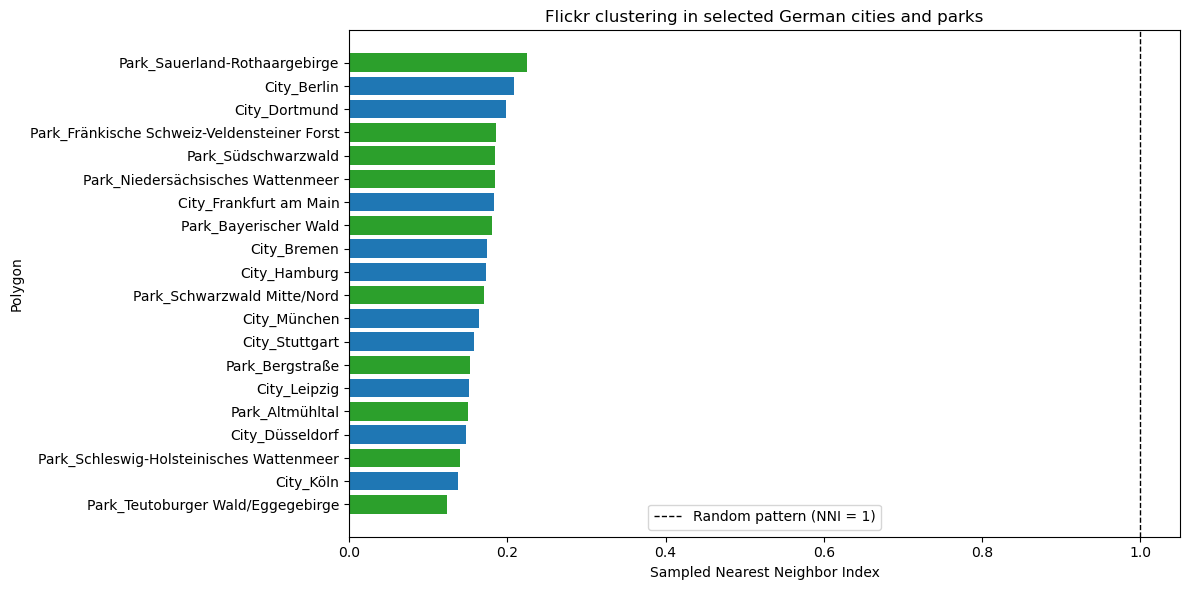

In [15]:
import matplotlib.pyplot as plt

if len(recommended_nni.dropna(subset=["nni"])) > 0:
    plot_df = recommended_nni.dropna(subset=["nni"]).sort_values("nni")
    colors = plot_df["polygon_type"].map({"City": "#1f77b4", "Park": "#2ca02c"})

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(plot_df["polygon_name"], plot_df["nni"], color=colors)
    ax.axvline(1.0, color="black", linewidth=1, linestyle="--", label="Random pattern (NNI = 1)")
    ax.set_xlabel("Sampled Nearest Neighbor Index")
    ax.set_ylabel("Polygon")
    ax.set_title("Flickr clustering in selected German cities and parks")
    ax.legend()
    plt.tight_layout()
    plt.show()

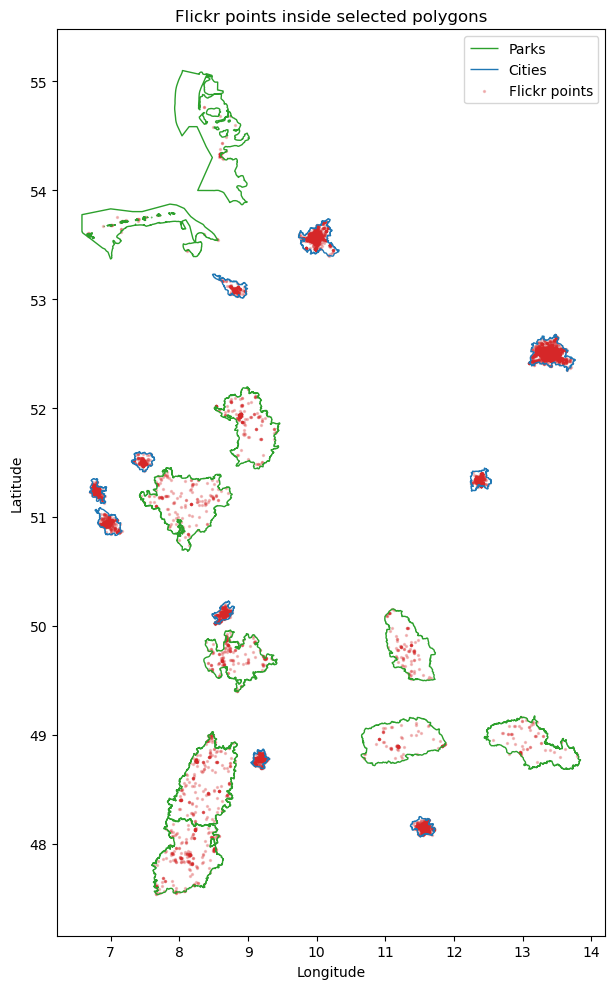

In [16]:
import matplotlib.pyplot as plt

if len(inside_points_df) > 0:
    cities_plot = gpd.read_file(GEOJSON_CITIES).to_crs(epsg=4326)
    parks_plot = gpd.read_file(GEOJSON_PARKS).to_crs(epsg=4326)

    plot_points = inside_points_df.drop_duplicates("PhotoID")
    if len(plot_points) > 20000:
        plot_points = plot_points.sample(20000, random_state=RANDOM_SEED)

    fig, ax = plt.subplots(figsize=(9, 10))
    parks_plot.boundary.plot(ax=ax, color="#2ca02c", linewidth=1, label="Parks")
    cities_plot.boundary.plot(ax=ax, color="#1f77b4", linewidth=1, label="Cities")
    ax.scatter(plot_points["Longitude"], plot_points["Latitude"], s=2, alpha=0.25, color="#d62728", label="Flickr points")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Flickr points inside selected polygons")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [17]:
print("Output-Dateien:")
print(f"Kompilierte Flickr-Punkte: {COMPILED_CSV}")
print(f"Bounding-Box-Kandidaten: {CANDIDATE_CSV}")
print(f"PIP-Ergebnisse: {FILTERED_CSV}")
print(f"Sampled/thinned NNI Ergebnisse: {NNI_RESULTS_CSV}")
print(f"Sampled-query NNI Ergebnisse: {NNI_QUERY_RESULTS_CSV}")

Output-Dateien:
Kompilierte Flickr-Punkte: ./outputs/all_flickr_points.csv
Bounding-Box-Kandidaten: ./outputs/flickr_bbox_candidates.csv
PIP-Ergebnisse: ./outputs/filtered_flickr_inside_polygons.csv
Sampled/thinned NNI Ergebnisse: ./outputs/nni_results_sampled.csv
Sampled-query NNI Ergebnisse: ./outputs/nni_results_sampled_query.csv
